In [1]:
from collections import Counter
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

from util.python.bpe_experiments import evaluate_bpe_with_tempdir
from util.python.protein_eda_artifacts import ensure_output_directories, write_manifest, write_table_outputs
from util.python.protein_fasta_io import parse_fasta_corpus
from util.python.tokenization_strategies import apply_residue_policy, summarize_token_frequencies, tokenize_overlapping_kmers, tokenize_single, validate_config

In [2]:
REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = "data/raw/prot_only_dehydrated/ncbi_dataset/data"
MAX_LENGTH = 512
TOKENIZATION_STRATEGIES = ["single", "3-mer", "5-mer", "BPE"]
AMBIGUOUS_RESIDUE_MODE = "keep"
RARE_RESIDUE_POLICY = "replace_with_unk"
SAMPLE_MODE = "all"
ANALYSIS_SCOPE_OVERRIDE = None
BPE_CANDIDATE_MODES = [1000, 4000, 8000]
RESIDUE_POLICY_SENSITIVITY_MODES = ["replace_with_unk", "normalize_selected", "drop_sequence"]
ARTIFACT_OUTPUT_DIR = "data/interim/protein_eda"
FIGURE_OUTPUT_DIR = "results/protein_eda/figures"
SAVE_ARTIFACTS = True
SAVE_FIGURES = True
CSV_PREVIEW_ROW_LIMIT = 5000

# Protein Sequence EDA

This notebook implements the phase-1 evidence gathering workflow for protein FASTA corpus profiling and pretraining-oriented analysis.


In [3]:
validate_config(
    tokenization_strategies=TOKENIZATION_STRATEGIES,
    ambiguous_residue_mode=AMBIGUOUS_RESIDUE_MODE,
    rare_residue_policy=RARE_RESIDUE_POLICY,
)

data_root_path = REPO_ROOT / DATA_ROOT
artifact_output_path = REPO_ROOT / ARTIFACT_OUTPUT_DIR
figure_output_path = REPO_ROOT / FIGURE_OUTPUT_DIR
results_output_path = figure_output_path.parent

if not data_root_path.exists():
    raise FileNotFoundError(f"DATA_ROOT does not exist: {data_root_path}")

ensure_output_directories(artifact_output_path, figure_output_path, results_output_path)

run_config = {
    "data_root": DATA_ROOT,
    "max_length": MAX_LENGTH,
    "tokenization_strategies": TOKENIZATION_STRATEGIES,
    "ambiguous_residue_mode": AMBIGUOUS_RESIDUE_MODE,
    "rare_residue_policy": RARE_RESIDUE_POLICY,
    "sample_mode": SAMPLE_MODE,
    "analysis_scope_override": ANALYSIS_SCOPE_OVERRIDE,
    "bpe_candidate_modes": BPE_CANDIDATE_MODES,
    "residue_policy_sensitivity_modes": RESIDUE_POLICY_SENSITIVITY_MODES,
    "artifact_output_dir": str(artifact_output_path),
    "figure_output_dir": str(figure_output_path),
    "save_artifacts": SAVE_ARTIFACTS,
    "save_figures": SAVE_FIGURES,
}

display(pd.DataFrame([run_config]).T)

,0
data_root,data/raw/prot_only_dehydrated/ncbi_dataset/data
max_length,512
tokenization_strategies,"[single, 3-mer, 5-mer, BPE]"
ambiguous_residue_mode,keep
rare_residue_policy,replace_with_unk
sample_mode,all
analysis_scope_override,None
bpe_candidate_modes,"[1000, 4000, 8000]"
residue_policy_sensitivity_modes,"[replace_with_unk, normalize_selected, drop_se..."
artifact_output_dir,/home/ubuntu/projects/biodata/DNA-BERT/data/in...


## Parse Corpus

Parse every available `protein.faa` file, preserve provenance, and surface malformed records or headers.


In [4]:
records_list = []
for records, issues in parse_fasta_corpus(data_root_path):
    if issues:
        print("Sample issues:")
        for issue in issues[:5]:
            print(f" - {issue}")

    records_list.extend([record.to_dict() for record in records])

records_df = pd.DataFrame(records_list)
header_fields_df = pd.json_normalize(records_df["header_fields"]).add_prefix("header_")
records_df = pd.concat([records_df.drop(columns=["header_fields"]), header_fields_df], axis=1)
records_df.head()

Discovered 22141 FASTA files in /home/ubuntu/projects/biodata/DNA-BERT/data/raw/prot_only_dehydrated/ncbi_dataset/data


Parsing FASTA files:   0%|          | 0/20 [00:00<?, ?it/s]

,sequence_id,assembly_id,name,file_path,contains_ambiguous_residue,header_is_malformed,raw_header,sequence_length,sequence,parse_status,annotations,letter_annotations,issue,header_sequence_id_token,header_header_remainder,header_header_annotations
0,NP_414542.1,GCF_000005845.2,NP_414542.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,NP_414542.1 thr operon leader peptide [Escheri...,21,MKRISTTITTTITITTGNGAG,parsed,None,None,None,NP_414542.1,thr operon leader peptide [Escherichia coli st...,[Escherichia coli str. K-12 substr. MG1655]
1,NP_414543.1,GCF_000005845.2,NP_414543.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,NP_414543.1 fused aspartate kinase/homoserine ...,820,MRVLKFGGTSVANAERFLRVADILESNARQGQVATVLSAPAKITNH...,parsed,None,None,None,NP_414543.1,fused aspartate kinase/homoserine dehydrogenas...,[Escherichia coli str. K-12 substr. MG1655]
2,NP_414544.1,GCF_000005845.2,NP_414544.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,NP_414544.1 homoserine kinase [Escherichia col...,310,MVKVYAPASSANMSVGFDVLGAAVTPVDGALLGDVVTVEAAETFSL...,parsed,None,None,None,NP_414544.1,homoserine kinase [Escherichia coli str. K-12 ...,[Escherichia coli str. K-12 substr. MG1655]
3,NP_414545.1,GCF_000005845.2,NP_414545.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,NP_414545.1 threonine synthase [Escherichia co...,428,MKLYNLKDHNEQVSFAQAVTQGLGKNQGLFFPHDLPEFSLTEIDEM...,parsed,None,None,None,NP_414545.1,threonine synthase [Escherichia coli str. K-12...,[Escherichia coli str. K-12 substr. MG1655]
4,NP_414546.1,GCF_000005845.2,NP_414546.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,NP_414546.1 DUF2502 domain-containing protein ...,98,MKKMQSIVLALSLVLVAPMAAQAAEITLVPSVKLQIGDRDNRGYYW...,parsed,None,None,None,NP_414546.1,DUF2502 domain-containing protein YaaX [Escher...,[Escherichia coli str. K-12 substr. MG1655]


In [5]:
records_df.to_csv(artifact_output_path / "protein_records.csv", index=False)

In [6]:
records_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55585 entries, 0 to 55584
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   sequence_id                 55585 non-null  object
 1   assembly_id                 55585 non-null  object
 2   name                        55585 non-null  object
 3   file_path                   55585 non-null  object
 4   contains_ambiguous_residue  55585 non-null  bool  
 5   header_is_malformed         55585 non-null  bool  
 6   raw_header                  55585 non-null  object
 7   sequence_length             55585 non-null  int64 
 8   sequence                    55585 non-null  object
 9   parse_status                55585 non-null  object
 10  annotations                 0 non-null      object
 11  letter_annotations          0 non-null      object
 12  issue                       0 non-null      object
 13  header_sequence_id_token    55585 non-null  ob

## Sequence Profiling

Compute corpus-level sequence statistics, residue composition, and ambiguity summaries.


In [7]:
length_thresholds = [128, 256, 512, 1024]
threshold_summary_df = pd.DataFrame(
    [
        {
            "length_threshold": threshold,
            "sequence_count": int((records_df["sequence_length"] > threshold).sum()),
            "fraction": float((records_df["sequence_length"] > threshold).mean()),
        }
        for threshold in tqdm(length_thresholds, desc="Evaluating length thresholds", leave=False)
    ]
)

residue_counter = Counter()
for sequence in tqdm(records_df["sequence"], desc="Counting residues", total=len(records_df), leave=False):
    residue_counter.update(sequence)
residue_frequency_df = pd.DataFrame(sorted(residue_counter.items()), columns=["residue", "count"]).sort_values("count", ascending=False).reset_index(drop=True)

ambiguous_residue_df = residue_frequency_df[~residue_frequency_df["residue"].isin(list("ACDEFGHIKLMNPQRSTVWY"))].copy()

sequence_stats_df = records_df[
    [
        "assembly_id",
        "file_path",
        "sequence_id",
        "raw_header",
        "sequence_length",
        "contains_ambiguous_residue",
        "header_is_malformed",
        "parse_status",
    ]
].copy()

display(threshold_summary_df)
display(residue_frequency_df.head(20))
display(ambiguous_residue_df if not ambiguous_residue_df.empty else pd.DataFrame(columns=["residue", "count"]))

Evaluating length thresholds:   0%|          | 0/4 [00:00<?, ?it/s]

Counting residues:   0%|          | 0/55585 [00:00<?, ?it/s]

,length_threshold,sequence_count,fraction
0,128,46177,0.830746
1,256,29689,0.534119
2,512,7138,0.128416
3,1024,704,0.012665


,residue,count
0,L,1879024
1,A,1685377
2,G,1307839
3,V,1201903
4,I,1089266
5,E,1077441
6,S,1045186
7,R,1015780
8,D,912499
9,K,876893


,residue,count
20,U,29
21,X,17
22,J,2


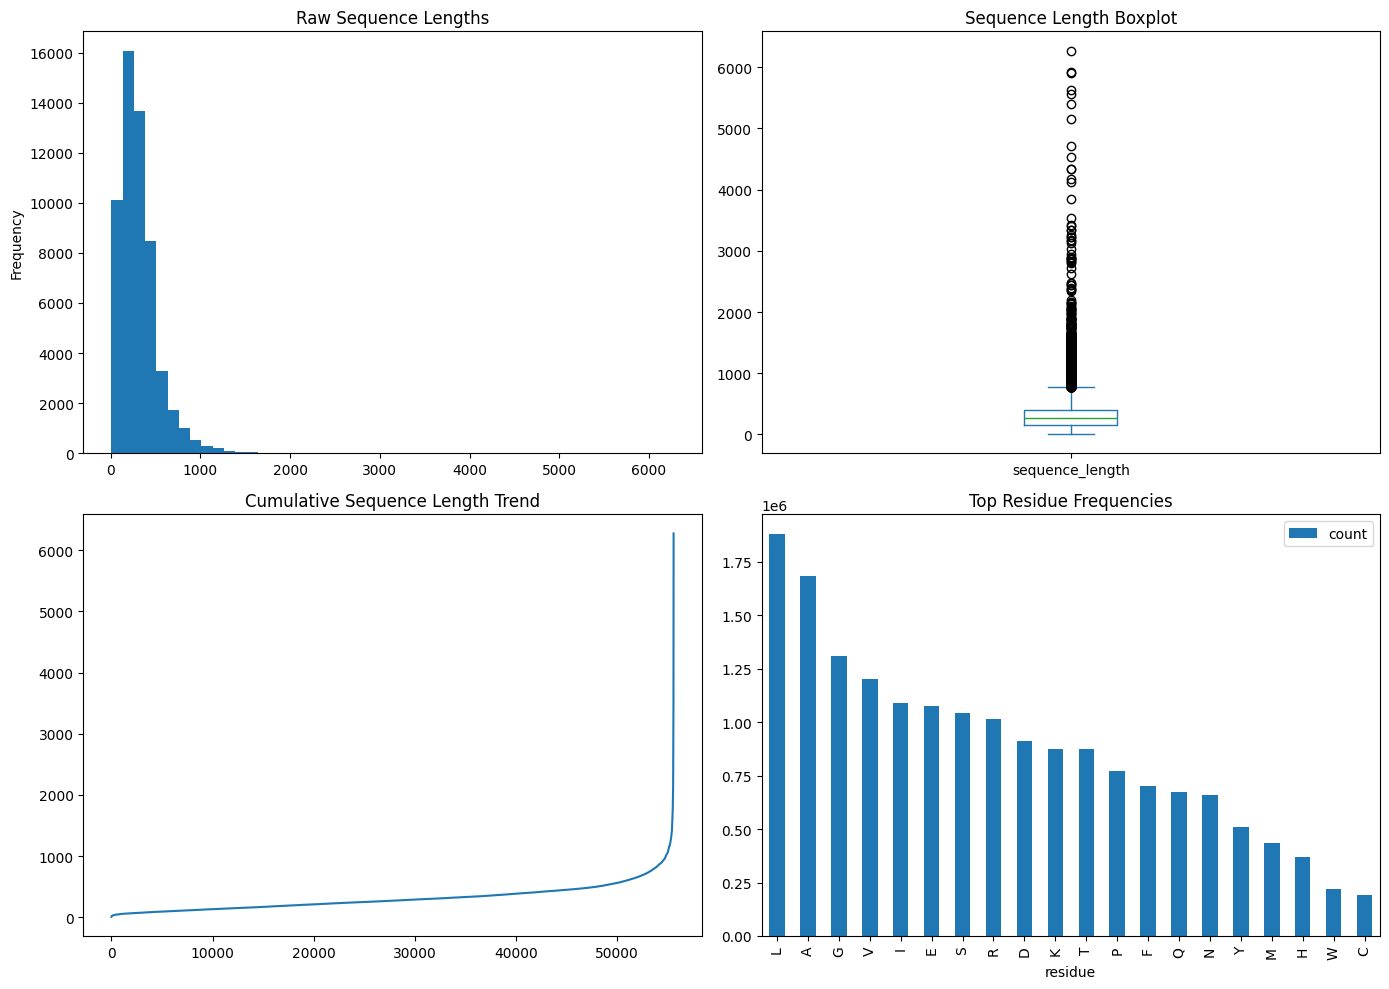

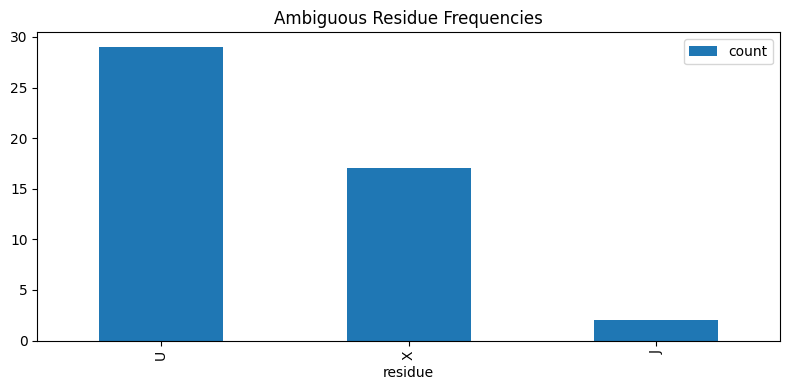

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
records_df["sequence_length"].plot(kind="hist", bins=50, ax=axes[0, 0], title="Raw Sequence Lengths")
records_df[["sequence_length"]].plot(kind="box", ax=axes[0, 1], title="Sequence Length Boxplot")
records_df["sequence_length"].sort_values().reset_index(drop=True).plot(ax=axes[1, 0], title="Cumulative Sequence Length Trend")
residue_frequency_df.head(20).plot(kind="bar", x="residue", y="count", ax=axes[1, 1], title="Top Residue Frequencies")
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(figure_output_path / "raw_sequence_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

if not ambiguous_residue_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ambiguous_residue_df.plot(kind="bar", x="residue", y="count", ax=ax, title="Ambiguous Residue Frequencies")
    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(figure_output_path / "ambiguous_residue_frequencies.png", dpi=150, bbox_inches="tight")
    plt.show()

## Duplicate and Metadata Preview

Build raw and deduplicated views plus a metadata preview table for later curation.


,view_name,duplicate_scope,duplicate_group_count,duplicate_sequence_count,duplicate_rate
0,raw_provenance,overall,1849,4058,0.073005
1,raw_provenance,within_assembly,601,601,0.010812
2,raw_provenance,across_assemblies,3457,3457,0.062193
3,deduplicated_candidate,overall,0,0,0.000000


,assembly_id,file_path,sequence_id,raw_header,header_sequence_id_token,header_header_remainder,header_is_malformed
0,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414542.1,NP_414542.1 thr operon leader peptide [Escheri...,NP_414542.1,thr operon leader peptide [Escherichia coli st...,False
1,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414543.1,NP_414543.1 fused aspartate kinase/homoserine ...,NP_414543.1,fused aspartate kinase/homoserine dehydrogenas...,False
2,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414544.1,NP_414544.1 homoserine kinase [Escherichia col...,NP_414544.1,homoserine kinase [Escherichia coli str. K-12 ...,False
3,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414545.1,NP_414545.1 threonine synthase [Escherichia co...,NP_414545.1,threonine synthase [Escherichia coli str. K-12...,False
4,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414546.1,NP_414546.1 DUF2502 domain-containing protein ...,NP_414546.1,DUF2502 domain-containing protein YaaX [Escher...,False
5,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414547.1,NP_414547.1 DNA binding and peroxide stress re...,NP_414547.1,DNA binding and peroxide stress response prote...,False
6,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414548.1,NP_414548.1 putative transporter YaaJ [Escheri...,NP_414548.1,putative transporter YaaJ [Escherichia coli st...,False
7,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414549.1,NP_414549.1 transaldolase B [Escherichia coli ...,NP_414549.1,transaldolase B [Escherichia coli str. K-12 su...,False
8,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414550.1,NP_414550.1 molybdopterin adenylyltransferase ...,NP_414550.1,molybdopterin adenylyltransferase [Escherichia...,False
9,GCF_000005845.2,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,NP_414551.1,NP_414551.1 acetate/succinate:H(+) symporter [...,NP_414551.1,acetate/succinate:H(+) symporter [Escherichia ...,False


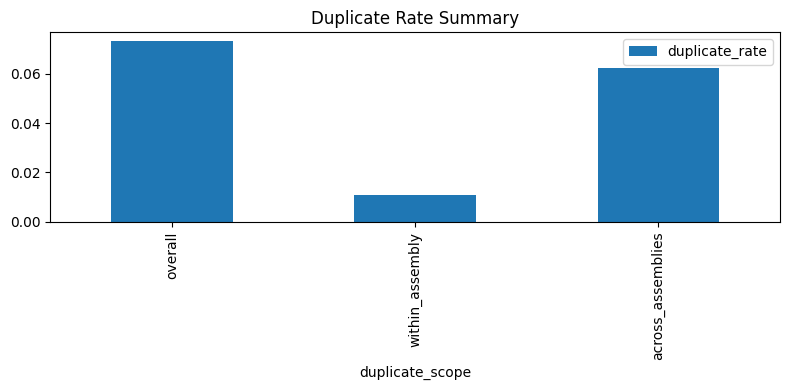

In [9]:
raw_duplicate_mask = records_df.duplicated(subset=["sequence"], keep=False)
raw_duplicate_groups = records_df[raw_duplicate_mask].groupby("sequence").size()
deduplicated_candidate_df = records_df.drop_duplicates(subset=["sequence"]).copy()

within_assembly_duplicate_count = int(records_df.duplicated(subset=["assembly_id", "sequence"], keep=False).sum())
across_assemblies_duplicate_count = int(raw_duplicate_mask.sum() - within_assembly_duplicate_count)
duplicate_summary_df = pd.DataFrame(
    [
        {
            "view_name": "raw_provenance",
            "duplicate_scope": "overall",
            "duplicate_group_count": int(len(raw_duplicate_groups)),
            "duplicate_sequence_count": int(raw_duplicate_mask.sum()),
            "duplicate_rate": float(raw_duplicate_mask.mean()),
        },
        {
            "view_name": "raw_provenance",
            "duplicate_scope": "within_assembly",
            "duplicate_group_count": int(within_assembly_duplicate_count),
            "duplicate_sequence_count": int(within_assembly_duplicate_count),
            "duplicate_rate": float(within_assembly_duplicate_count / len(records_df)),
        },
        {
            "view_name": "raw_provenance",
            "duplicate_scope": "across_assemblies",
            "duplicate_group_count": int(max(across_assemblies_duplicate_count, 0)),
            "duplicate_sequence_count": int(max(across_assemblies_duplicate_count, 0)),
            "duplicate_rate": float(max(across_assemblies_duplicate_count, 0) / len(records_df)),
        },
        {
            "view_name": "deduplicated_candidate",
            "duplicate_scope": "overall",
            "duplicate_group_count": 0,
            "duplicate_sequence_count": 0,
            "duplicate_rate": 0.0,
        },
    ]
)

header_metadata_preview_df = records_df[
    [
        "assembly_id",
        "file_path",
        "sequence_id",
        "raw_header",
        "header_sequence_id_token",
        "header_header_remainder",
        "header_is_malformed",
    ]
].copy()

display(duplicate_summary_df)
display(header_metadata_preview_df.head(20))

fig, ax = plt.subplots(figsize=(8, 4))
duplicate_summary_df[duplicate_summary_df["view_name"] == "raw_provenance"].plot(
    kind="bar",
    x="duplicate_scope",
    y="duplicate_rate",
    ax=ax,
    title="Duplicate Rate Summary",
)
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(figure_output_path / "duplicate_rate_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
artifacts = []
if SAVE_ARTIFACTS:
    artifacts.extend(write_table_outputs(sequence_stats_df, artifact_output_path / "sequence_stats.parquet", artifact_output_path / "sequence_stats_preview.csv", CSV_PREVIEW_ROW_LIMIT))
    artifacts.extend(write_table_outputs(duplicate_summary_df, artifact_output_path / "duplicate_summary.parquet", artifact_output_path / "duplicate_summary_preview.csv", CSV_PREVIEW_ROW_LIMIT))
    artifacts.extend(
        write_table_outputs(header_metadata_preview_df, artifact_output_path / "header_metadata_preview.parquet", artifact_output_path / "header_metadata_preview.csv", CSV_PREVIEW_ROW_LIMIT)
    )

manifest = {
    "run_date": pd.Timestamp.utcnow().isoformat(),
    "data_root": DATA_ROOT,
    "max_length": MAX_LENGTH,
    "sample_mode": SAMPLE_MODE,
    "analysis_scope_override": ANALYSIS_SCOPE_OVERRIDE,
    "tokenization_strategies": TOKENIZATION_STRATEGIES,
    "ambiguous_residue_mode": AMBIGUOUS_RESIDUE_MODE,
    "rare_residue_policy": RARE_RESIDUE_POLICY,
    "artifacts": artifacts,
}

if SAVE_ARTIFACTS:
    write_manifest(manifest, results_output_path / "analysis_artifact_manifest.json")

display(pd.DataFrame(artifacts))
display(pd.DataFrame([manifest]).drop(columns=["artifacts"]))

,artifact_name,artifact_role,storage_format,path,analysis_scope,source_view,is_preview
0,sequence_stats,table,parquet,/home/ubuntu/projects/biodata/DNA-BERT/data/in...,configured,None,False
1,sequence_stats_preview,table,csv,/home/ubuntu/projects/biodata/DNA-BERT/data/in...,configured,None,True
2,duplicate_summary,table,parquet,/home/ubuntu/projects/biodata/DNA-BERT/data/in...,configured,None,False
3,duplicate_summary_preview,table,csv,/home/ubuntu/projects/biodata/DNA-BERT/data/in...,configured,None,True
4,header_metadata_preview,table,parquet,/home/ubuntu/projects/biodata/DNA-BERT/data/in...,configured,None,False
5,header_metadata_preview,table,csv,/home/ubuntu/projects/biodata/DNA-BERT/data/in...,configured,None,True


,run_date,data_root,max_length,sample_mode,analysis_scope_override,tokenization_strategies,ambiguous_residue_mode,rare_residue_policy
0,2026-03-11T13:13:47.186065+00:00,data/raw/prot_only_dehydrated/ncbi_dataset/data,512,all,None,"[single, 3-mer, 5-mer, BPE]",keep,replace_with_unk
